In [2]:
# ==========================================
# SETUP INIZIALE E INSTALLAZIONE DIPENDENZE
# ==========================================

# Installazione silenziosa (-q) delle librerie necessarie per il progetto
!pip install -q pandas scikit-learn matplotlib seaborn

# ==========================================
# IMPORTAZIONE DELLE LIBRERIE
# ==========================================

# 1. Livello di Elaborazione Dati
import pandas as pd
import numpy as np

# 2. Livello di Intelligenza Artificiale (Modello e Validazione)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 3. Livello di Presentazione (Grafici)
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafica per Jupyter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup completato con successo. Ambiente pronto per l'ingestion dei dati.")

Setup completato con successo. Ambiente pronto per l'ingestion dei dati.


In [3]:
# ==========================================
# CELLA 2: IMPORTAZIONE E ISPEZIONE DATI
# ==========================================

# Definizione dei percorsi dei file
# NOTA: Assicurarsi di aver scaricato i file da Kaggle e averli posizionati
# nella stessa cartella in cui è salvato questo Notebook.
path_generation = 'Plant_1_Generation_Data.csv'
path_weather = 'Plant_1_Weather_Sensor_Data.csv'

try:
    # 1. Caricamento dei dataset grezzi
    df_generation = pd.read_csv(path_generation)
    df_weather = pd.read_csv(path_weather)

    # 2. Ottimizzazione: Conversione immediata delle colonne temporali in formato Datetime
    # Questo standardizza il formato per permettere una fusione perfetta tra i due dataset
    df_generation['DATE_TIME'] = pd.to_datetime(df_generation['DATE_TIME'])
    df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'])

    # 3. Feedback per l'utente (utile durante la presentazione)
    print("Operazione completata: Dataset caricati in memoria con successo.")
    print(f"-> Dimensioni dati generazione (Pannello): {df_generation.shape}")
    print(f"-> Dimensioni dati meteo (Sensori): {df_weather.shape}\n")

    # Mostriamo un'anteprima elegante delle prime righe per confermare la corretta lettura
    display("Anteprima Dati di Generazione:", df_generation.head(3))
    display("Anteprima Dati Meteo:", df_weather.head(3))

except FileNotFoundError:
    print("ERRORE DI SISTEMA: Impossibile trovare i file CSV.")
    print("Azione richiesta: Verificare che 'Plant_1_Generation_Data.csv' e 'Plant_1_Weather_Sensor_Data.csv' siano presenti nella cartella corrente.")

Operazione completata: Dataset caricati in memoria con successo.
-> Dimensioni dati generazione (Pannello): (68778, 7)
-> Dimensioni dati meteo (Sensori): (3182, 6)



/tmp/ipykernel_1612/1787995540.py:18: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_generation['DATE_TIME'] = pd.to_datetime(df_generation['DATE_TIME'])


'Anteprima Dati di Generazione:'

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0


'Anteprima Dati Meteo:'

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0


In [6]:
# ==========================================
# CELLA 3: DATA PREPARATION & FEATURE ENGINEERING
# ==========================================

print("Avvio elaborazione e fusione dei dataset...")

# 1. Pulizia Dati Generazione
# Aggreghiamo i dati di tutti gli inverter sommandone la produzione
# per avere il totale dell'intero impianto.
df_gen_grouped = df_generation.groupby('DATE_TIME').agg({
    'DC_POWER': 'sum',
    'AC_POWER': 'sum',
    'DAILY_YIELD': 'sum'
}).reset_index()

# 2. Fusione dei Dataset (Merge)
# Uniamo i dati aggregati del pannello con le rilevazioni meteorologiche.
df_merged = pd.merge(df_gen_grouped, df_weather, on='DATE_TIME', how='inner')

# Rimuoviamo colonne non necessarie per il modello
colonne_da_rimuovere = ['PLANT_ID', 'SOURCE_KEY']
df_merged = df_merged.drop(columns=[col for col in colonne_da_rimuovere if col in df_merged.columns])

# 3. Impostazione indice e Campionamento Orario (Semplificazione a 60 min)
# Trasformiamo i dati da scansioni di 15 minuti a medie orarie pulite
df_merged = df_merged.set_index('DATE_TIME')
df_merged = df_merged.resample('1H').mean()
df_merged = df_merged.dropna() # Rimuoviamo eventuali ore senza rilevazioni

# 4. Feature Engineering
# Estraiamo informazioni dall'orario per aiutare l'algoritmo
df_merged['HOUR'] = df_merged.index.hour
df_merged['MONTH'] = df_merged.index.month

# Feedback finale e visualizzazione mirata
print("Elaborazione completata con successo.")
print(f"-> Dimensioni dataset finale (campionamento orario): {df_merged.shape}")

# Selezioniamo per la visualizzazione solo dati diurni (es. le ore 12:00)
# per mostrare valori di produzione significativi
dati_diurni = df_merged[df_merged['HOUR'] == 12].head(3)

print("\nAnteprima Dati (Rilevazioni significative ore 12:00):")
display(dati_diurni)

Avvio elaborazione e fusione dei dataset...
Elaborazione completata con successo.
-> Dimensioni dataset finale (campionamento orario): (796, 8)

Anteprima Dati (Rilevazioni significative ore 12:00):


/tmp/ipykernel_1612/3461316807.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_merged = df_merged.resample('1H').mean()


,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MONTH
DATE_TIME,,,,,,,,
2020-05-15 12:00:00,193173.708337,18885.107738,66648.879465,31.837944,50.503143,0.678330,12,5
2020-05-16 12:00:00,209359.486607,20465.747767,75374.906252,30.643569,50.862354,0.695447,12,5
2020-05-17 12:00:00,206562.379465,20181.870089,93598.410715,33.059760,56.041961,0.731459,12,5


In [11]:
# ==========================================
# CELLA 4: VALIDAZIONE E ADDESTRAMENTO
# ==========================================

print("Preparazione dei dati per il Machine Learning...")

# [AGGIUNTA/MODIFICA]: Rimossa 'MODULE_TEMPERATURE'.
# Usiamo solo variabili disponibili in una vera previsione meteo per il giorno dopo.
features = ['AMBIENT_TEMPERATURE', 'IRRADIATION', 'HOUR', 'MONTH']
target = 'DC_POWER'

X = df_merged[features].copy()

# Introduciamo un errore casuale (rumore gaussiano) per simulare
# l'incertezza di una vera previsione meteorologica.
import numpy as np
np.random.seed(42)
errore_meteo = np.random.normal(1, 0.25, len(X))
X['IRRADIATION'] = X['IRRADIATION'] * errore_meteo
X['AMBIENT_TEMPERATURE'] = X['AMBIENT_TEMPERATURE'] * np.random.normal(1, 0.10, len(X))

y = df_merged[target]

# Inizializzazione del Modello
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# K-Fold Cross Validation
print("Esecuzione K-Fold Cross Validation (5 split)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print(f"-> Punteggi R^2 sui 5 fold: {np.round(cv_scores, 4)}")
print(f"-> R^2 Medio (Affidabilità generale): {cv_scores.mean():.4f}\n")

# Divisione Train/Test e Addestramento Finale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Addestramento del modello finale sul Train Set...")
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Addestramento completato con successo.")
print(f"-> Metriche sul Test Set | R^2: {test_r2:.4f} | RMSE: {test_rmse:.2f} kW")

Preparazione dei dati per il Machine Learning...
Esecuzione K-Fold Cross Validation (5 split)...
-> Punteggi R^2 sui 5 fold: [0.9468 0.9698 0.9522 0.9332 0.9428]
-> R^2 Medio (Affidabilità generale): 0.9490

Addestramento del modello finale sul Train Set...
Addestramento completato con successo.
-> Metriche sul Test Set | R^2: 0.9424 | RMSE: 20476.89 kW


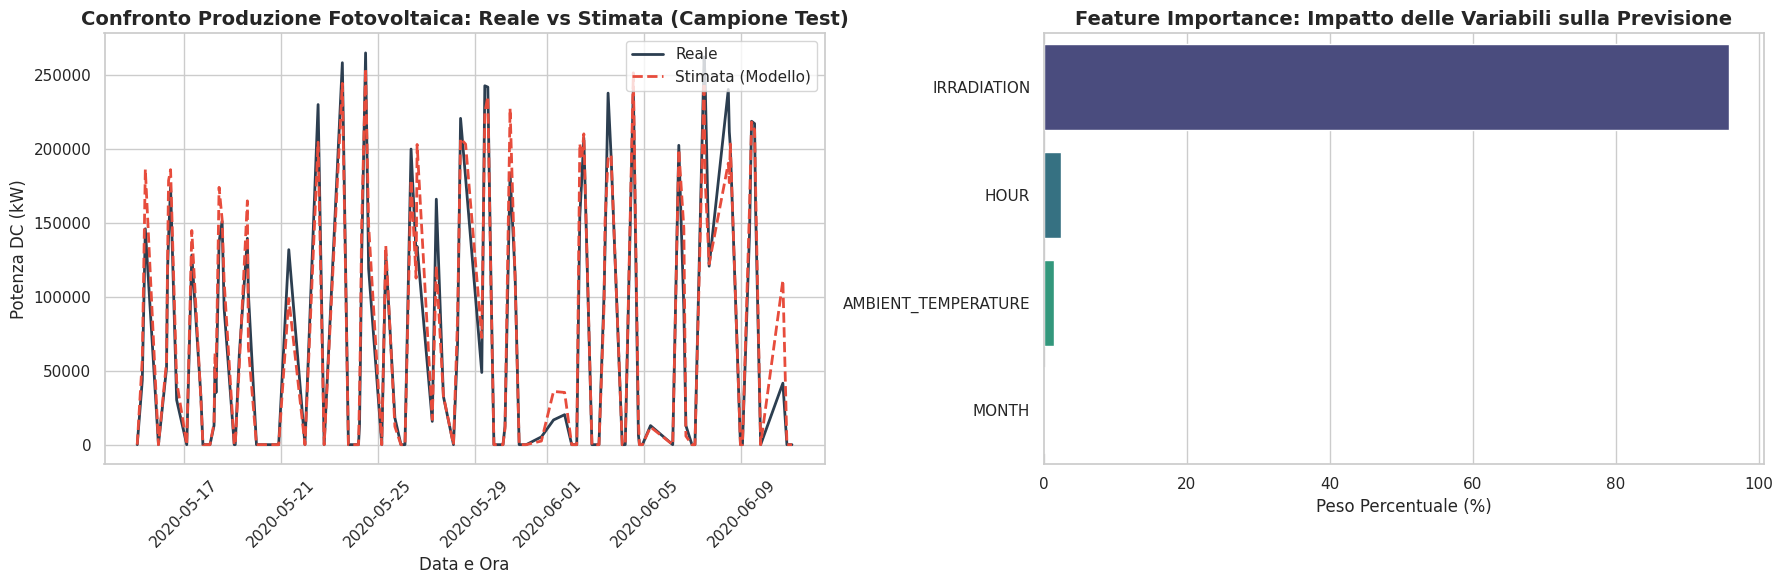

Classifica analitica dell'importanza delle variabili:


,Variabile,Importanza (%)
1,IRRADIATION,95.87
2,HOUR,2.45
0,AMBIENT_TEMPERATURE,1.48
3,MONTH,0.20


In [12]:
# ==========================================
# CELLA 5: VALUTAZIONE VARIABILI E PRESENTAZIONE
# ==========================================

# Estrazione della Feature Importance
importances = rf_model.feature_importances_
df_importanza = pd.DataFrame({
    'Variabile': features,
    'Importanza (%)': importances * 100
}).sort_values(by='Importanza (%)', ascending=False)

# Preparazione dei dati per il grafico temporale
df_risultati = pd.DataFrame({
    'Produzione Reale': y_test,
    'Produzione Stimata': y_pred
}, index=X_test.index).sort_index()

df_risultati_subset = df_risultati.head(120)

# Generazione delle Dashboard Visive
fig, assi = plt.subplots(1, 2, figsize=(18, 6))

# Grafico A: Andamento Temporale
assi[0].plot(df_risultati_subset.index, df_risultati_subset['Produzione Reale'],
             label='Reale', color='#2c3e50', linewidth=2)
assi[0].plot(df_risultati_subset.index, df_risultati_subset['Produzione Stimata'],
             label='Stimata (Modello)', color='#e74c3c', linestyle='--', linewidth=2)
assi[0].set_title('Confronto Produzione Fotovoltaica: Reale vs Stimata (Campione Test)', fontsize=14, fontweight='bold')
assi[0].set_ylabel('Potenza DC (kW)', fontsize=12)
assi[0].set_xlabel('Data e Ora', fontsize=12)
assi[0].legend(loc='upper right')
assi[0].tick_params(axis='x', rotation=45)

# Grafico B: Feature Importance
# [MODIFICA]: Aggiunto parametro hue='Variabile' e legend=False per risolvere il FutureWarning di Seaborn
sns.barplot(x='Importanza (%)', y='Variabile', data=df_importanza, ax=assi[1], palette='viridis', hue='Variabile', legend=False)
assi[1].set_title('Feature Importance: Impatto delle Variabili sulla Previsione', fontsize=14, fontweight='bold')
assi[1].set_xlabel('Peso Percentuale (%)', fontsize=12)
assi[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Classifica analitica dell'importanza delle variabili:")
display(df_importanza.round(2))